# **Импорты**

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re, os, gdown, time
import matplotlib.pyplot as plt

# **Загрузка и подготовка данных**

In [ ]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

!unzip -o writers.zip -d writers/

FILE_DIR = 'writers'
SIG_TRAIN = 'обучающая'
SIG_TEST = 'тестовая'

CLASS_LIST = []
text_train = []
text_test = []

file_list = os.listdir(FILE_DIR)
for file_name in file_list:
    m = re.match(r'\((.+)\) (\S+)_', file_name)
    if m:
        class_name = m[1]
        subset_name = m[2].lower()
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name
        if is_train or is_test:
            if class_name not in CLASS_LIST:
                CLASS_LIST.append(class_name)
                text_train.append('')
                text_test.append('')
            cls = CLASS_LIST.index(class_name)
            with open(f'{FILE_DIR}/{file_name}', 'r', encoding='utf-8') as f:
                text = f.read()
            subset = text_train if is_train else text_test
            subset[cls] += ' ' + text.replace('\n', ' ')

CLASS_COUNT = len(CLASS_LIST)
print("Classes:", CLASS_LIST)

Archive:  writers.zip
  inflating: writers/(Клиффорд_Саймак) Обучающая_5 вместе.txt  
  inflating: writers/(Клиффорд_Саймак) Тестовая_2 вместе.txt  
  inflating: writers/(Макс Фрай) Обучающая_5 вместе.txt  
  inflating: writers/(Макс Фрай) Тестовая_2 вместе.txt  
  inflating: writers/(О. Генри) Обучающая_50 вместе.txt  
  inflating: writers/(О. Генри) Тестовая_20 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Обучающая_22 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Тестовая_8 вместе.txt  
  inflating: writers/(Стругацкие) Обучающая_5 вместе.txt  
  inflating: writers/(Стругацкие) Тестовая_2 вместе.txt  
  inflating: writers/(Булгаков) Обучающая_5 вместе.txt  
  inflating: writers/(Булгаков) Тестовая_2 вместе.txt  
Classes: ['О. Генри', 'Макс Фрай', 'Клиффорд_Саймак', 'Булгаков', 'Рэй Брэдберри', 'Стругацкие']


# **Токенизатор**

In [ ]:

class Tokenizer:
    def __init__(self, num_words=None, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True, split=' '):
        self.num_words = num_words
        self.filters = filters
        self.lower = lower
        self.split = split
        self.word_index = {}
        self.word_counts = Counter()

    def fit_on_texts(self, texts):
        for text in texts:
            if self.lower:
                text = text.lower()
            for ch in self.filters:
                text = text.replace(ch, ' ')
            words = text.split(self.split)
            self.word_counts.update(words)
        most_common = self.word_counts.most_common(self.num_words if self.num_words else None)
        for i, (word, _) in enumerate(most_common, 1):
            self.word_index[word] = i

    def texts_to_sequences(self, texts):
        sequences = []
        for text in texts:
            if self.lower:
                text = text.lower()
            for ch in self.filters:
                text = text.replace(ch, ' ')
            words = text.split(self.split)
            seq = [self.word_index.get(word, 0) for word in words if word]
            sequences.append(seq)
        return sequences

# **Разбиение на окна**

In [ ]:

def get_samples(sequences, win_size, win_hop):
    x_samples, y_samples = [], []
    for class_idx, seq in enumerate(sequences):
        if len(seq) < win_size:
            continue
        for start in range(0, len(seq) - win_size + 1, win_hop):
            x_samples.append(seq[start:start+win_size])
            y_samples.append(class_idx)
    return np.array(x_samples), np.array(y_samples)

class TextDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# **Модель**

In [ ]:

class Conv1DClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, win_size, num_classes):
        super().__init__()
        # Увеличиваем размер эмбеддинга, чтобы вместить все индексы от 0 до vocab_size
        self.embedding = nn.Embedding(vocab_size + 1, embedding_dim, padding_idx=0)
        self.spatial_dropout = nn.Dropout1d(0.2)
        self.batch_norm = nn.BatchNorm1d(embedding_dim)
        self.conv1 = nn.Conv1d(embedding_dim, 20, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(0.2)
        self.flatten = nn.Flatten()
        # Правильный расчёт длины после MaxPool1d
        pooled_len = (win_size + 1) // 2
        self.fc = nn.Linear(20 * pooled_len, num_classes)

    def forward(self, x):
        emb = self.embedding(x)                     # (B, L, E)
        emb = emb.permute(0, 2, 1)                  # (B, E, L)
        emb = self.spatial_dropout(emb)
        emb = self.batch_norm(emb)
        out = self.conv1(emb)
        out = self.relu(out)
        out = self.pool(out)                        # (B, 20, L/2)
        out = self.dropout(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

# **Обучение**

In [ ]:

def train_model(model, train_loader, val_loader, epochs, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            _, pred = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (pred == labels).sum().item()
        history['loss'].append(train_loss / train_total)
        history['accuracy'].append(train_correct / train_total)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, pred = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (pred == labels).sum().item()
        history['val_loss'].append(val_loss / val_total)
        history['val_accuracy'].append(val_correct / val_total)
        best_val_acc = max(best_val_acc, val_correct / val_total)

    return history, best_val_acc

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history['accuracy'], label='Train')
    ax1.plot(history['val_accuracy'], label='Val')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(); ax1.grid(True)

    ax2.plot(history['loss'], label='Train')
    ax2.plot(history['val_loss'], label='Val')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(); ax2.grid(True)
    plt.show()

# **Создание потока обучения для разных параметров**

In [ ]:

class timex:
    def __enter__(self):
        self.t = time.time()
        return self
    def __exit__(self, *args):
        print(f'Время обработки: {time.time() - self.t:.2f} с')

def run_experiment(vocab_size, win_size, win_hop, epochs=20, device='cuda' if torch.cuda.is_available() else 'cpu'):
    tokenizer = Tokenizer(num_words=vocab_size)
    tokenizer.fit_on_texts(text_train)
    seq_train = tokenizer.texts_to_sequences(text_train)
    seq_test = tokenizer.texts_to_sequences(text_test)

    x_train, y_train = get_samples(seq_train, win_size, win_hop)
    x_test, y_test = get_samples(seq_test, win_size, win_hop)

    if len(x_train) == 0 or len(x_test) == 0:
        print("Пустая выборка – пропускаем")
        return 0.0

    # Проверка индексов
    max_idx = max(x_train.max(), x_test.max())
    print(f"Размер словаря: {vocab_size}, максимальный индекс: {max_idx}")
    if max_idx > vocab_size:
        print(f"⚠️ Индекс {max_idx} превышает vocab_size {vocab_size}, увеличиваю эмбеддинг")
        vocab_size = max_idx  # корректируем vocab_size для модели

    train_ds = TextDataset(x_train, y_train)
    test_ds = TextDataset(x_test, y_test)
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

    model = Conv1DClassifier(vocab_size, 50, win_size, CLASS_COUNT).to(device)
    with timex():
        history, best_acc = train_model(model, train_loader, test_loader, epochs, device)
        plot_training_history(history)
    return best_acc

# **Запуск обучения и вывод**


Тестирование VOCAB_SIZE = 5000...
Размер словаря: 5000, максимальный индекс: 5000


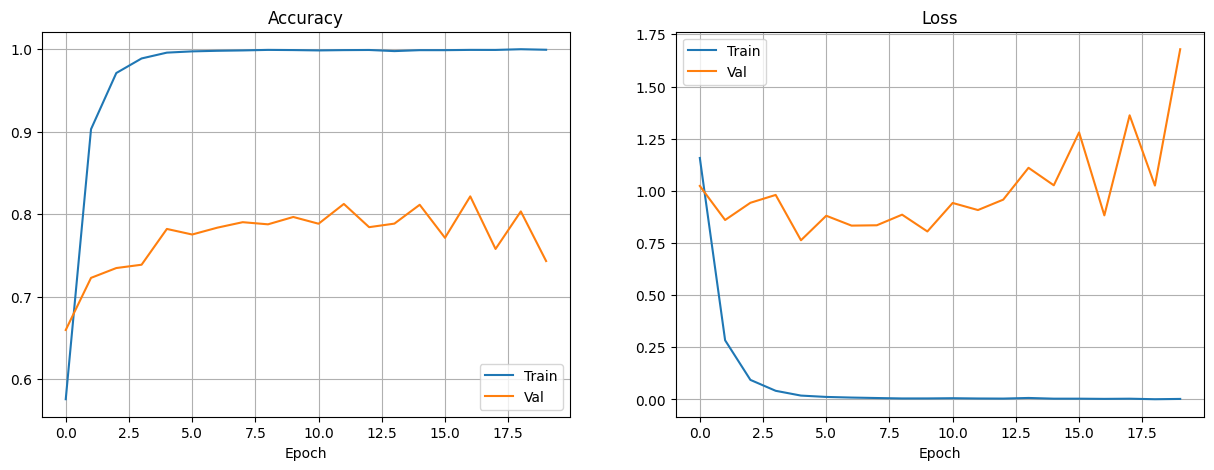

Время обработки: 524.95 с

Тестирование VOCAB_SIZE = 10000...
Размер словаря: 10000, максимальный индекс: 10000
Время обработки: 24.62 с


KeyboardInterrupt: 

In [ ]:

results = []
vocab_values = [5000, 10000, 20000, 40000]
for v in vocab_values:
    print(f'\nТестирование VOCAB_SIZE = {v}...')
    acc = run_experiment(v, 1000, 100)
    results.append({'VOCAB_SIZE': v, 'WIN_SIZE': 1000, 'WIN_HOP': 100, 'Accuracy': acc})

window_values = [(500, 50), (2000, 200)]
for w_size, w_hop in window_values:
    print(f'\nТестирование WIN_SIZE = {w_size}, WIN_HOP = {w_hop}...')
    acc = run_experiment(20000, w_size, w_hop)
    results.append({'VOCAB_SIZE': 20000, 'WIN_SIZE': w_size, 'WIN_HOP': w_hop, 'Accuracy': acc})


print('\n{:<12} | {:<10} | {:<10} | {:<10}'.format('VOCAB_SIZE', 'WIN_SIZE', 'WIN_HOP', 'Accuracy'))
print('-' * 50)
for res in results:
    print(f"{res['VOCAB_SIZE']:<12} | {res['WIN_SIZE']:<10} | {res['WIN_HOP']:<10} | {res['Accuracy']:<10.4f}")